# Option Pricing Workflow (Version 2)

This notebook runs the full project workflow using the rewritten package.

## Steps
1. Import the package and configure the run.
2. Fetch the daily SOFR risk-free rate and record it.
3. Download and clean market data.
4. Compute returns and volatility inputs.
5. Build strike and maturity inputs.
6. Price European and American options with the CRR model, and price European options with the BSM model.
7. Save summary outputs.

## 1. Imports and Configuration

Set the ticker, date range, and model assumptions for the run.

In [3]:
import importlib
import sys
from pathlib import Path

# Make the src-based package importable in JupyterLab without extra setup.
project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Clear cached package modules so notebook reruns pick up recent edits.
for module_name in list(sys.modules):
    if module_name == "option_pricing" or module_name.startswith("option_pricing."):
        sys.modules.pop(module_name)
importlib.invalidate_caches()

src_path

PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/src')

In [4]:
from datetime import date

import matplotlib.pyplot as plt
import pandas as pd

from option_pricing.config import get_project_paths
from option_pricing.data_helper import clean_price_data, fetch_latest_sofr_rate, get_price_data, remove_existing_files, save_csv, validate_ticker
from option_pricing.pricing_model import bsm_price_grid, build_pricing_inputs, crr_price_grid
from option_pricing.volatility import add_log_returns, build_horizon_volatility_table, forecast_garch_volatility, rolling_volatility

paths = get_project_paths()
ticker = "AAPL"
start_date = (pd.Timestamp.today().normalize() - pd.DateOffset(years=3)).date().isoformat()
end_date = date.today().isoformat()
sofr_info = fetch_latest_sofr_rate()
risk_free_rate = sofr_info.rate_decimal

# Keep only the latest workflow outputs, even if the ticker or date range changes.
remove_existing_files(paths.raw_data, "*_prices.csv")
remove_existing_files(paths.processed_data, ["SOFR_rate*.csv", "*_returns.csv", "*_volatility_inputs.csv"])
remove_existing_files(paths.tables, ["*_bsm_european_prices.csv", "*_crr_american_prices.csv", "*_crr_european_prices.csv", "*_european_model_comparison.csv"])
remove_existing_files(paths.figures, "*_workflow_summary.png")

assert validate_ticker(ticker), f"Ticker {ticker} is not available."
paths

ProjectPaths(root=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)'), data=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/data'), raw_data=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/data/raw'), processed_data=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/data/processed'), docs=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/docs'), notebooks=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/notebooks'), outputs=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/outputs'), figures=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/outputs/figures'), tables=PosixPath('/Users/allenpilipala/Notebooks/Option Pricing Model (Binomial Tree & BSM)/outputs/tables'))

## 2. Daily SOFR Risk-Free Rate

Use the daily Secured Overnight Financing Rate (SOFR) as the risk-free rate input. The package fetches the latest published SOFR observation, stores both the quoted percent and decimal form, and saves a one-row record for reproducibility.

In [6]:
sofr_output = paths.processed_data / "SOFR_rate.csv"
save_csv(sofr_info.to_frame(), sofr_output)
sofr_info.to_frame()

,observation_date,rate_percent,rate_decimal,series,source
0,2026-03-31,3.68,0.0368,SOFR,"FRED (Federal Reserve Bank of St. Louis), sour..."


## 3. Acquire and Clean Market Data

Download daily prices, standardize the dataframe, and save a raw snapshot.

In [8]:
prices = get_price_data(ticker=ticker, start=start_date, end=end_date)
prices = clean_price_data(prices)

raw_output = paths.raw_data / f"{ticker}_prices.csv"
save_csv(prices, raw_output)
prices.tail()

,date,adj_close,close,high,low,open,volume
559,2026-03-26,252.889999,252.889999,257.000000,250.770004,252.119995,41796700
560,2026-03-27,248.800003,248.800003,255.490005,248.070007,253.899994,47900000
561,2026-03-30,246.630005,246.630005,250.869995,245.509995,250.070007,39446200
562,2026-03-31,253.789993,253.789993,255.479996,247.100006,247.910004,49549600
563,2026-04-01,254.210007,254.210007,256.179993,253.330002,254.300003,9649387


## 4. Compute Returns and Volatility

Build log returns, rolling volatility, historical horizon volatility, and GARCH horizon volatility.

In [10]:
returns_df = add_log_returns(prices, price_column="adj_close")
rolling_df = rolling_volatility(prices, window=21, price_column="adj_close")
historical_vol = build_horizon_volatility_table(prices, ticker=ticker, price_column="adj_close")
garch_vol = forecast_garch_volatility(prices, ticker=ticker, price_column="adj_close")
volatility_table = pd.concat([historical_vol, garch_vol], ignore_index=True)

processed_returns_path = paths.processed_data / f"{ticker}_returns.csv"
processed_vol_path = paths.processed_data / f"{ticker}_volatility_inputs.csv"
save_csv(returns_df, processed_returns_path)
save_csv(volatility_table, processed_vol_path)
volatility_table

,ticker,model,horizon_days,sigma,annualized_sigma
0,AAPL,historical,1,0.017248,0.273798
1,AAPL,historical,2,0.024392,0.273798
2,AAPL,historical,3,0.029874,0.273798
3,AAPL,historical,4,0.034495,0.273798
4,AAPL,historical,5,0.038567,0.273798
5,AAPL,garch,1,0.015364,0.243897
6,AAPL,garch,2,0.015482,0.173790
7,AAPL,garch,3,0.015590,0.142883
8,AAPL,garch,4,0.015687,0.124513
9,AAPL,garch,5,0.015776,0.111996


## 5. Visual Review

Create simple charts for the adjusted close series and rolling volatility.

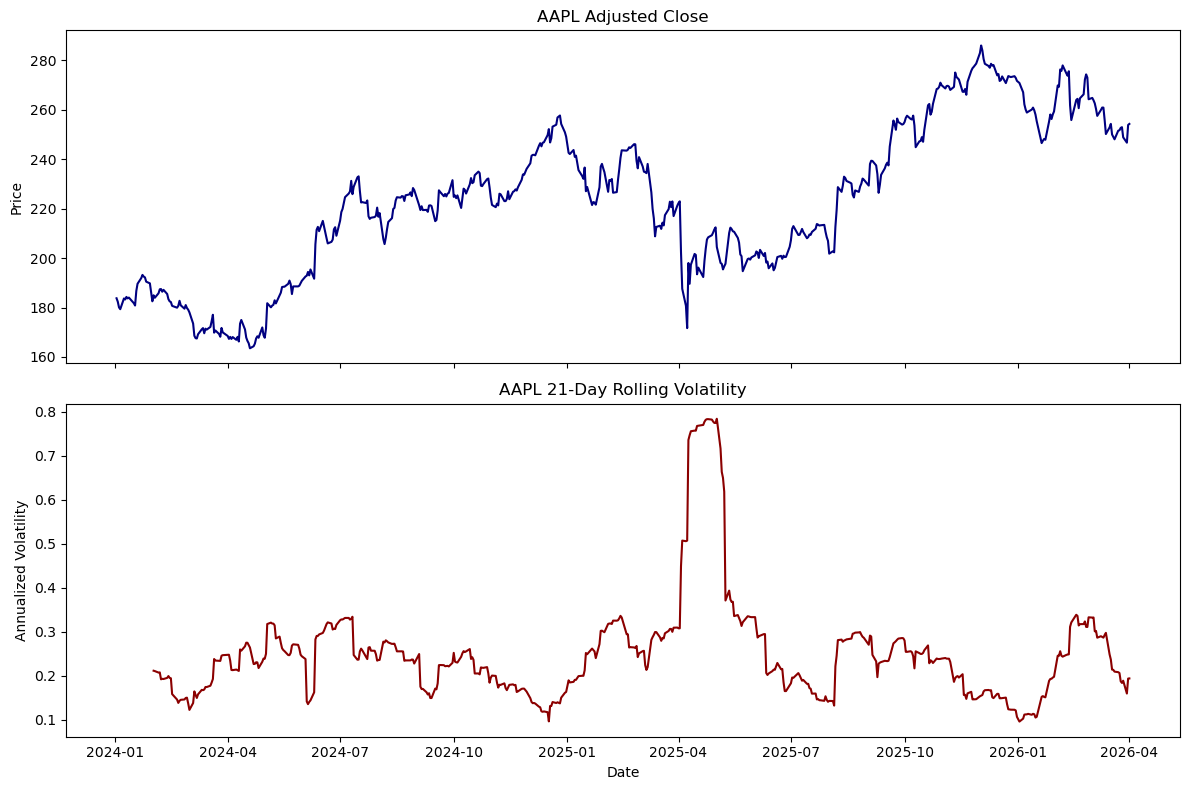

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(prices["date"], prices["adj_close"], color="navy")
axes[0].set_title(f"{ticker} Adjusted Close")
axes[0].set_ylabel("Price")

axes[1].plot(rolling_df["date"], rolling_df["rolling_volatility"], color="darkred")
axes[1].set_title(f"{ticker} 21-Day Rolling Volatility")
axes[1].set_ylabel("Annualized Volatility")
axes[1].set_xlabel("Date")

plt.tight_layout()
figure_path = paths.figures / f"{ticker}_workflow_summary.png"
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

## 6. Build Pricing Inputs

Use the latest adjusted close as the spot price, create a strike grid, and keep the 1-5 day volatility inputs.

In [14]:
spot_price = float(prices["adj_close"].iloc[-1])
strike_grid, pricing_inputs = build_pricing_inputs(
    ticker=ticker,
    spot_price=spot_price,
    volatility_table=volatility_table,
    risk_free_rate=risk_free_rate,
    horizons=range(1, 6),
)

spot_price, strike_grid, pricing_inputs.head()

(254.2100067138672,
 array([252.21, 253.21, 254.21, 255.21, 256.21]),
   ticker       model  horizon_days     sigma  annualized_sigma  spot_price  \
 0   AAPL  historical             1  0.017248          0.273798  254.210007   
 1   AAPL  historical             2  0.024392          0.273798  254.210007   
 2   AAPL  historical             3  0.029874          0.273798  254.210007   
 3   AAPL  historical             4  0.034495          0.273798  254.210007   
 4   AAPL  historical             5  0.038567          0.273798  254.210007   
 
    risk_free_rate  
 0          0.0368  
 1          0.0368  
 2          0.0368  
 3          0.0368  
 4          0.0368  )

## 7. Run Pricing Models

Use CRR for both exercise styles and use BSM only for the European benchmark.

In [16]:
bsm_results = bsm_price_grid(
    ticker=ticker,
    spot_price=spot_price,
    risk_free_rate=risk_free_rate,
    strike_grid=strike_grid,
    volatility_table=pricing_inputs,
)

crr_american_results = crr_price_grid(
    ticker=ticker,
    spot_price=spot_price,
    risk_free_rate=risk_free_rate,
    strike_grid=strike_grid,
    volatility_table=pricing_inputs,
    exercise_style="american",
)

crr_european_results = crr_price_grid(
    ticker=ticker,
    spot_price=spot_price,
    risk_free_rate=risk_free_rate,
    strike_grid=strike_grid,
    volatility_table=pricing_inputs,
    exercise_style="european",
)

bsm_results.head(), crr_american_results.head(), crr_european_results.head()

(  ticker  spot_price  strike  maturity_days vol_model   sigma_h  sigma_annual  \
 0   AAPL  254.210007  252.21              1     garch  0.015364      0.243897   
 1   AAPL  254.210007  253.21              1     garch  0.015364      0.243897   
 2   AAPL  254.210007  254.21              1     garch  0.015364      0.243897   
 3   AAPL  254.210007  255.21              1     garch  0.015364      0.243897   
 4   AAPL  254.210007  256.21              1     garch  0.015364      0.243897   
 
    risk_free_rate  call_bsm   put_bsm  
 0          0.0368  2.778306  0.741472  
 1          0.0368  2.128153  1.091172  
 2          0.0368  1.576653  1.539526  
 3          0.0368  1.126728  2.089455  
 4          0.0368  0.774819  2.737400  ,
   ticker  spot_price  strike  maturity_days vol_model   sigma_h  sigma_annual  \
 0   AAPL  254.210007  252.21              1     garch  0.015364      0.243897   
 1   AAPL  254.210007  253.21              1     garch  0.015364      0.243897   
 2   AAPL  25

## 8. Compare and Save Results

Save the American and European CRR results, then compare the European CRR prices with the European BSM prices.

In [18]:
european_comparison = bsm_results.merge(
    crr_european_results,
    on=["ticker", "spot_price", "strike", "maturity_days", "vol_model", "sigma_h", "sigma_annual", "risk_free_rate"],
    how="inner",
)

save_csv(bsm_results, paths.tables / f"{ticker}_bsm_european_prices.csv")
save_csv(crr_american_results, paths.tables / f"{ticker}_crr_american_prices.csv")
save_csv(crr_european_results, paths.tables / f"{ticker}_crr_european_prices.csv")
save_csv(european_comparison, paths.tables / f"{ticker}_european_model_comparison.csv")
european_comparison.head(10)

,ticker,spot_price,strike,maturity_days,vol_model,sigma_h,sigma_annual,risk_free_rate,call_bsm,put_bsm,call_crr,put_crr
0,AAPL,254.210007,252.21,1,garch,0.015364,0.243897,0.0368,2.778306,0.741472,2.972909,0.936074
1,AAPL,254.210007,253.21,1,garch,0.015364,0.243897,0.0368,2.128153,1.091172,2.472070,1.435089
2,AAPL,254.210007,254.21,1,garch,0.015364,0.243897,0.0368,1.576653,1.539526,1.971232,1.934105
3,AAPL,254.210007,255.21,1,garch,0.015364,0.243897,0.0368,1.126728,2.089455,1.470393,2.433120
4,AAPL,254.210007,256.21,1,garch,0.015364,0.243897,0.0368,0.774819,2.737400,0.969555,2.932136
5,AAPL,254.210007,252.21,2,garch,0.015482,0.173790,0.0368,2.814420,0.740763,2.936062,0.862405
6,AAPL,254.210007,253.21,2,garch,0.015482,0.173790,0.0368,2.162013,1.088063,2.182365,1.108416
7,AAPL,254.210007,254.21,2,garch,0.015482,0.173790,0.0368,1.607312,1.533070,1.428668,1.372836
8,AAPL,254.210007,255.21,2,garch,0.015482,0.173790,0.0368,1.153396,2.078862,1.174790,2.118741
9,AAPL,254.210007,256.21,2,garch,0.015482,0.173790,0.0368,0.797008,2.722183,0.920916,2.864647


## 9. Final Notes

This notebook is the single workflow notebook for version 2. In the pricing stage, CRR is used for both American and European options, while BSM is used only for the European benchmark. All reusable logic lives in `src/option_pricing`, while processed datasets are written to `data/processed` and generated charts and tables are written to `docs/`.